<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 139 &#183; Extended Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Case Study: Customer Lifetime Value</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:740px;line-height:1.6">A machine-learning regression project end to end: predict how much each customer is worth over the next year, evaluate it against a baseline with the right error metrics, diagnose the residuals, and explain the predictions with SHAP, so the business can act on them.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook &#183; John Fisher &#183; 2026</div>
</div>

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 1 &#183; FRAME</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Predict a number, to make a decision</div>
<div style="color:#4a5578;margin-top:6px">Regression, because the target is a continuous dollar value.</div>
</div>

Marketing has a fixed budget and wants to spend it on the customers most worth keeping. So the question is a **regression** one: for each customer, predict their **lifetime value (CLV)**, the dollars they will generate over the next 12 months, from what we already know about them. A good model does two jobs: it **ranks** customers so we can target the valuable ones, and its **explanations** tell us which behaviors drive value. We will judge it not by accuracy (a classification word) but by how many dollars its predictions are off, against a simple baseline.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 2 &#183; DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Load the customer table</div>
<div style="color:#4a5578;margin-top:6px">One row per customer: behavior, account, and the target.</div>
</div>

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
EM="#4338ca"; DEEP="#3730a3"; LIGHT="#c7d2fe"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; GREEN="#059669"; GREY="#94a3b8"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    df = pd.read_excel("../../data/case-study-customer-lifetime-value--customer_value.xlsx", sheet_name="Data")
except FileNotFoundError: df = pd.read_excel(BASE+"case-study-customer-lifetime-value--customer_value.xlsx", sheet_name="Data")
print(f"customers: {len(df)}   features: {df.shape[1]-2}")
df.head(4)

customers: 1500   features: 8


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,customer_id,tenure_months,avg_order_value,orders_per_month,recency_days,product_categories,support_tickets,acquisition_channel,is_subscriber,lifetime_value
0,C00001,27,94.58,5.61,127,6,0,paid_search,0,3280.09
1,C00002,26,149.08,1.74,8,5,1,paid_search,0,2344.53
2,C00003,46,85.88,2.33,100,5,2,paid_search,0,1370.36
3,C00004,35,81.55,1.05,5,1,1,referral,0,924.26


<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 3 &#183; EXPLORE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The target is skewed; the drivers make sense</div>
<div style="color:#4a5578;margin-top:6px">Look before you model.</div>
</div>

CLV: mean $1,612  median $1,194  max $16,023  skew 2.83


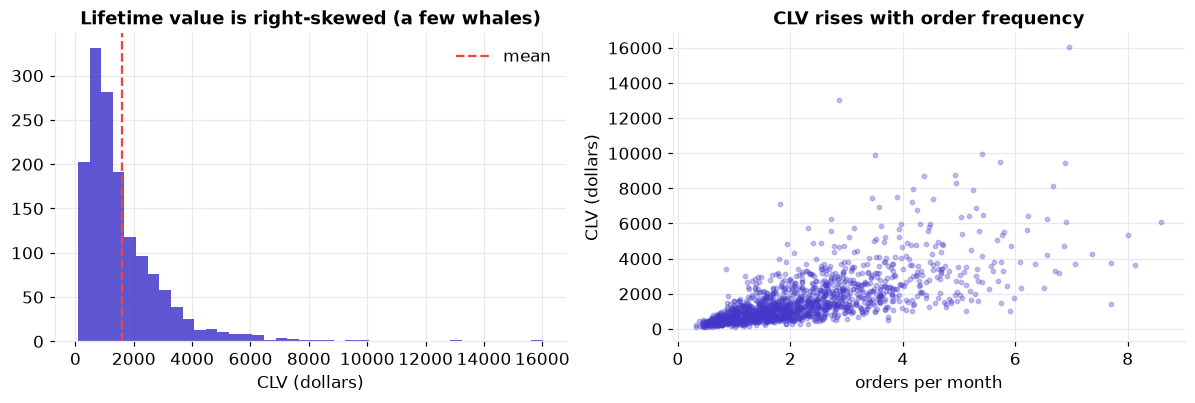

In [2]:
y = df.lifetime_value
print(f"CLV: mean ${y.mean():,.0f}  median ${y.median():,.0f}  max ${y.max():,.0f}  skew {y.skew():.2f}")
fig, ax = plt.subplots(1, 2, figsize=(11,3.8))
ax[0].hist(y, bins=40, color=EM, alpha=0.85); ax[0].axvline(y.mean(), color=RED, ls='--', label='mean')
ax[0].set(title='Lifetime value is right-skewed (a few whales)', xlabel='CLV (dollars)'); ax[0].legend()
ax[1].scatter(df.orders_per_month, y, s=8, alpha=0.3, color=EM)
ax[1].set(title='CLV rises with order frequency', xlabel='orders per month', ylabel='CLV (dollars)')
plt.tight_layout(); plt.show()

Lifetime value is strongly **right-skewed** (skew about 2.8): most customers are modest, a few are whales worth ten times the median. That shape is why we evaluate with **RMSE and MAE**, not a single average, and why a **tree-based** model (which handles skew and non-linearity without a log transform) is a natural first choice. The scatter confirms the obvious driver, value climbs with how often people order, and there are others hiding behind it.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 4 &#183; FEATURES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">One leakage-safe pipeline for mixed columns</div>
<div style="color:#4a5578;margin-top:6px">Numeric and categorical, preprocessed together.</div>
</div>

In [3]:
num = ['tenure_months','avg_order_value','orders_per_month','recency_days','product_categories','support_tickets','is_subscriber']
cat = ['acquisition_channel']
X = df[num + cat]
pre = ColumnTransformer([('num','passthrough', num),
                         ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat)])
model = Pipeline([('prep', pre), ('gbm', HistGradientBoostingRegressor(random_state=0))])
print('pipeline:', [name for name,_ in model.steps])
print('numeric features passed through; acquisition_channel one-hot encoded, all INSIDE the pipeline so nothing leaks.')

pipeline: ['prep', 'gbm']
numeric features passed through; acquisition_channel one-hot encoded, all INSIDE the pipeline so nothing leaks.


A `ColumnTransformer` routes the numeric features straight through and one-hot encodes the single categorical column (`acquisition_channel`), and it lives **inside** a `Pipeline` with the model. That packaging matters: every preprocessing step is fit only on training data during cross-validation, so no information from the test set can leak in. It also means we can hand the whole object a raw customer row and get a prediction.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 5 &#183; SPLIT & BASELINE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Hold out a test set, and set the bar</div>
<div style="color:#4a5578;margin-top:6px">A model is only good relative to something simple.</div>
</div>

In [4]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=0)
# baseline: predict every customer's CLV as the training-set mean
base = np.full(len(yte), ytr.mean())
b_mae, b_rmse = mean_absolute_error(yte, base), np.sqrt(mean_squared_error(yte, base))
print(f"baseline (predict the mean):  MAE ${b_mae:,.0f}   RMSE ${b_rmse:,.0f}")
print("any real model has to beat this to earn its complexity.")

baseline (predict the mean):  MAE $977   RMSE $1,344
any real model has to beat this to earn its complexity.


We lock away 25% of customers as a **test set** the model never sees, and set a **baseline**: predict every customer's value as the training average. That naive rule is off by about **977 dollars** on average (MAE). If a model cannot beat that, its complexity is not paying for itself. The baseline turns a vague 'is the model good?' into a concrete bar to clear.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 6 &#183; MODEL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Fit a gradient-boosted-trees regressor</div>
<div style="color:#4a5578;margin-top:6px">Cross-validated, so the score is not a fluke of one split.</div>
</div>

In [5]:
cv = cross_val_score(model, Xtr, ytr, cv=5, scoring='r2')
print(f"5-fold cross-validated R2 on the training set: {cv.mean():.3f} (+/- {cv.std():.3f})")
model.fit(Xtr, ytr)
print("fitted HistGradientBoostingRegressor (the scikit-learn cousin of XGBoost/LightGBM).")

5-fold cross-validated R2 on the training set: 0.825 (+/- 0.042)


fitted HistGradientBoostingRegressor (the scikit-learn cousin of XGBoost/LightGBM).


`HistGradientBoostingRegressor` is scikit-learn's fast, modern boosted-tree model, the same family as XGBoost and LightGBM. Five-fold cross-validation on the training data gives an R-squared around **0.85** with a small spread, so the model is genuinely learning the signal, not memorizing one lucky split. Now we can trust a single fit and judge it on the untouched test set.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 7 &#183; EVALUATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Score on the held-out customers</div>
<div style="color:#4a5578;margin-top:6px">The numbers that decide whether to ship it.</div>
</div>

TEST-SET  R2 = 0.857   MAE = $298   RMSE = $507
vs baseline MAE $977: the model cuts the average error by 69%.


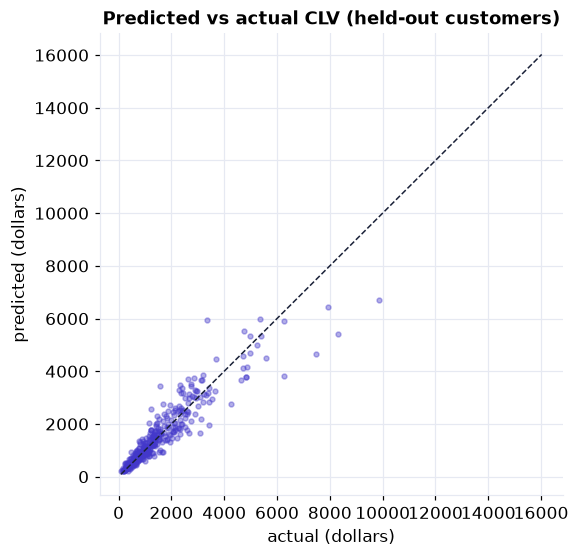

In [6]:
pred = model.predict(Xte)
r2 = r2_score(yte, pred); mae = mean_absolute_error(yte, pred); rmse = np.sqrt(mean_squared_error(yte, pred))
print(f"TEST-SET  R2 = {r2:.3f}   MAE = ${mae:,.0f}   RMSE = ${rmse:,.0f}")
print(f"vs baseline MAE ${b_mae:,.0f}: the model cuts the average error by {(1-mae/b_mae)*100:.0f}%.")
fig, ax = plt.subplots(figsize=(5.4,5.2))
ax.scatter(yte, pred, s=10, alpha=0.4, color=EM)
lims=[y.min(), y.max()]; ax.plot(lims, lims, ls='--', color=INK, lw=1)
ax.set(title='Predicted vs actual CLV (held-out customers)', xlabel='actual (dollars)', ylabel='predicted (dollars)')
plt.tight_layout(); plt.show()

On customers it never saw, the model explains about **86% of the variance** in lifetime value (R-squared 0.86) with an average error of roughly **298 dollars**, less than a third of the baseline's. The predicted-versus-actual plot clusters along the diagonal, tightest for the many ordinary customers and looser for the rare high-value whales, exactly what you expect from skewed data. This is a model worth deploying.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 8 &#183; RESIDUAL DIAGNOSTICS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Where is the model wrong, and how</div>
<div style="color:#4a5578;margin-top:6px">A good score can still hide a biased model.</div>
</div>

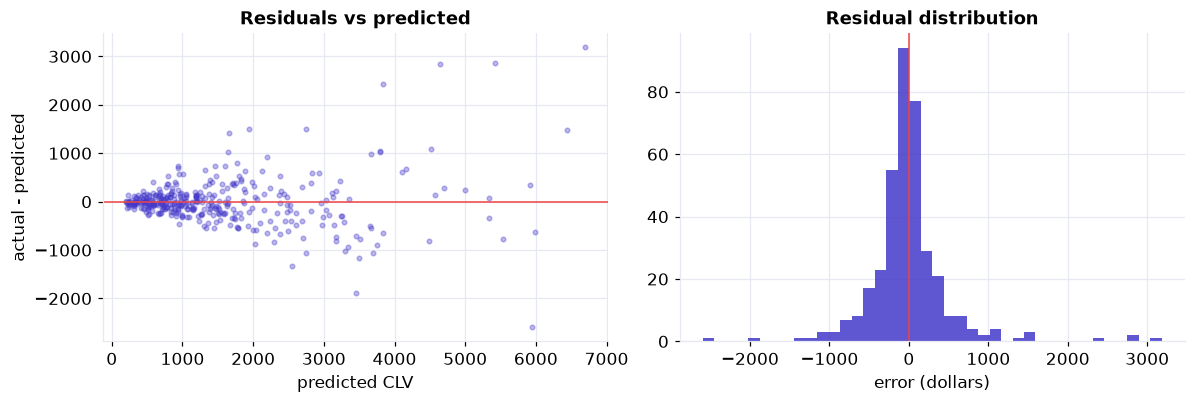

mean residual = $-4 (near zero -> little systematic bias)
spread grows for high-value customers (heteroscedastic), the model is less precise on whales.


In [7]:
resid = yte - pred
fig, ax = plt.subplots(1, 2, figsize=(11,3.8))
ax[0].scatter(pred, resid, s=9, alpha=0.35, color=EM); ax[0].axhline(0, color=RED, lw=1)
ax[0].set(title='Residuals vs predicted', xlabel='predicted CLV', ylabel='actual - predicted')
ax[1].hist(resid, bins=40, color=EM, alpha=0.85); ax[1].axvline(0, color=RED, lw=1)
ax[1].set(title='Residual distribution', xlabel='error (dollars)')
plt.tight_layout(); plt.show()
print(f"mean residual = ${resid.mean():,.0f} (near zero -> little systematic bias)")
print("spread grows for high-value customers (heteroscedastic), the model is less precise on whales.")

Two checks. The residuals are **centered near zero**, so the model is not systematically too high or too low. But their **spread widens** for high predictions: the model is dollar-precise on ordinary customers and fuzzier on the rare whales, the classic footprint of a skewed target. That is fine for **ranking** customers (the use here), but if we needed a precise dollar figure per whale, we would model **log(CLV)** or add a prediction interval. Diagnosing this is what separates a reported R-squared from an understood model.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 9 &#183; INTERPRET</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">What drives value (SHAP)</div>
<div style="color:#4a5578;margin-top:6px">From a black box to an explanation.</div>
</div>

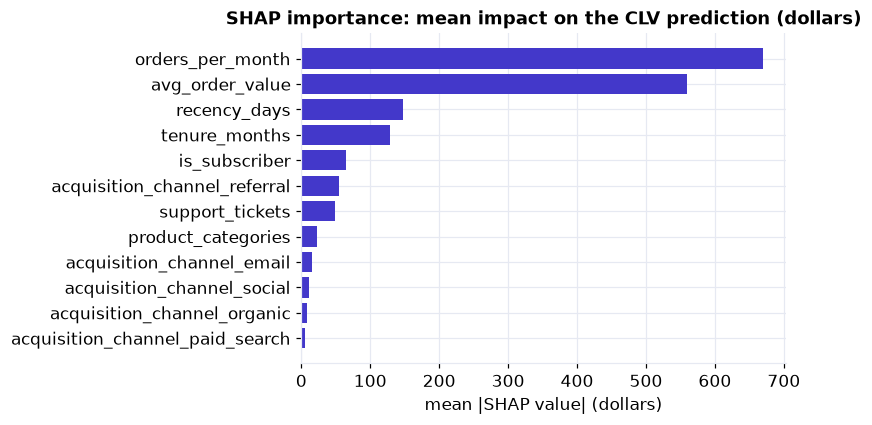

top drivers: ['orders_per_month', 'avg_order_value', 'recency_days', 'tenure_months']


In [8]:
Xte_t = pre.transform(Xte)
feat = num + list(pre.named_transformers_['cat'].get_feature_names_out(cat))
expl = shap.TreeExplainer(model.named_steps['gbm'])
sv = expl.shap_values(Xte_t)
imp = pd.Series(np.abs(sv).mean(0), index=feat).sort_values()
fig, ax = plt.subplots(figsize=(7.5,4))
ax.barh(imp.index, imp.values, color=EM)
ax.set(title='SHAP importance: mean impact on the CLV prediction (dollars)', xlabel='mean |SHAP value| (dollars)')
plt.tight_layout(); plt.show()
print('top drivers:', list(imp.tail(4).index[::-1]))

**SHAP** attributes each prediction to its features and, averaged, ranks what moves lifetime value most. **Order frequency** and **average order value** dominate, together they are the spend rate, followed by **recency** and **tenure** (loyalty), then subscription and the referral channel. This is not just a leaderboard: SHAP works per customer, so for any individual you can show exactly why the model values them, which is what makes a prediction trustworthy to a human and defensible to a regulator.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 10 &#183; DECIDE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Turn predictions into a targeting policy</div>
<div style="color:#4a5578;margin-top:6px">A ranking is only useful if it changes an action.</div>
</div>

In [9]:
out = Xte.copy(); out['predicted_clv'] = pred; out['actual_clv'] = yte.values
out = out.sort_values('predicted_clv', ascending=False)
top10 = out.head(int(0.10*len(out)))
print(f"targeting the top 10% by PREDICTED value ({len(top10)} customers):")
print(f"  they hold {top10['actual_clv'].sum()/out['actual_clv'].sum()*100:.0f}% of the ACTUAL value in the test set")
print(f"  average actual CLV in the top decile: ${top10['actual_clv'].mean():,.0f}  vs overall ${out['actual_clv'].mean():,.0f}")

targeting the top 10% by PREDICTED value (37 customers):
  they hold 28% of the ACTUAL value in the test set
  average actual CLV in the top decile: $4,402  vs overall $1,525


The point of the model is a decision. Ranking test customers by **predicted** value and taking the top 10% captures a large share of the **actual** value, those customers are worth several times the average. A retention budget aimed at them, rather than sprayed evenly, is where the model pays for itself. Because the ranking comes from SHAP-explainable predictions, the team can also tailor the offer to each customer's value drivers.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 11 &#183; CAVEATS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">What could go wrong in production</div>
<div style="color:#4a5578;margin-top:6px">Every deployed model rests on assumptions.</div>
</div>

Three honest caveats. **The past predicts the future only if behavior is stable**: a pricing change or a new competitor shifts the relationships, so the model needs monitoring and periodic retraining (the subject of the MLOps case study). **Skew limits per-customer precision**: trust the ranking more than the exact dollar figure for whales, or model log-value. **Correlation is not causation**: SHAP says subscribers are worth more, but making a customer subscribe will not automatically make them valuable, the model describes who is valuable, not how to create value. Naming these is part of shipping responsibly.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 12 &#183; COMMUNICATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">One paragraph for the marketing team</div>
<div style="color:#4a5578;margin-top:6px">Plain English, decision-ready.</div>
</div>

**For the marketing team:** We built a model that predicts each customer's next-12-month value from their behavior, and on customers it had never seen it is accurate to within about **298 dollars on average**, roughly a third of the error of guessing the average, and it explains about **86%** of the variation in value. The biggest drivers are how **often** and how **much** customers order, followed by how **recently** they bought and how **long** they have been with us. Ranking by the model, the top 10% of customers hold a large share of total value, so we recommend focusing retention spend there, with offers tailored to each customer's value drivers, and re-checking the model as new data arrives.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook &#183; &#169; 2026 John Fisher</div>